In [2]:
import numpy as np
from IPython.display import Image

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Устанавливаем глобальный seed для всех случайностей
np.random.seed(42)

# Непрерывная случайная величина

![title](../images/continuous_distributions.png)

# Теория вероятностей

![image](../images/random_variables.png)

Принципиальная разница(см. рисунок ниже) в том, что
* при дискретной случ. величине вероятность определяется для опр. исхода (появление 4-очков на игральной кости)
* для непрерывной случ. величины определяется вероятность попасть в интервал возможных значений величины Х( тапнуть в нижнюю часть экрана смартфона, нормированная координата по высоте от 0 до 0.5).

Как мы видим, вероятность появления, конкретного значения $Х=a$ для непрерывной величины (в точке) равна 0, потому, что длинна отрезка $[a,a]$, равна 0.

Здесь приведены примеры и свойства для:
* функции плотности вероятности `PDF`
* функции вероятности `PMF`

![image](../images/pdf_and_pmf.png)

## Распределения непрерывной случайной величины

Функция плотности вероятности (`PDF`) - обычно представлена непрерывной функций в виде аналитической формулы с параметрами распределения.

Свойства:
* Значения $PDF(X=x) \ge 0$
* Интеграл по области определения $\int_{A}^{B}PDF(x)\,\mathrm{d}x=1$

Рассмотрим `PDF` и ее свойства на модели нормального распределения $Norm(\mu, \sigma ^{2})$.

### Источник экспериментальных данных

И так у нас есть некоторый источник данных (случайная величина $x$), генерирующих последовательность $\left\lbrace x_1, x_2, x_3, ..., x_n\right\rbrace$:

```
[-0.26947439, 0.74256004, -0.46341769, -0.56572975, 0.24196227, -1.91328024, -1.52491783, 0.56228753]
```

Данные не повторяются, и используют всю доступную точность $float$, - мы имеем дело с непрерывной случайной величиной.

### Нормальное распределение $Norm(\mu, \sigma ^{2})$

`Normal distribution` - английский термин в статьях и фреймворках.

Модель нормального распределения $Norm(\mu, \sigma ^{2})$ с параметрами:
* $\mu$ — `математическое ожидание` (`первый момент случайной величины`), а так же `медиана` и единственная `мода`.

Свойства: Центр симметрии распределения, точка максимума `PDF`.

* $\sigma ^{2}$ — `дисперсия` (`второй момент случайной величины`). Корнем из нее будет параметр $\sigma$ - `среднеквадратичное отклонение`.

Свойства: Определяет ширину и высоту кривой `PDF`. Чем больше $\sigma$, тем шире и ниже кривая `PDF`.

> Зафиксировав значения параметров $Norm(\mu, \sigma ^{2})$ распределения $$\theta=\left\lbrace\mu=0,\sigma=1\right\rbrace$$ мы получаем точный статистический закон описывающий вероятностный процесс генерации всех наших данных, -  функцию плотности вероятности `PDF`) для непрерывной случ. величины.

#### Probability Density Function

Функция плотности вероятности (`PDF`) для нормального распределения:

$$f(x)=Norm(\mu, \sigma ^{2} \mid x)={\frac{1}{\sqrt{2\;\pi\sigma^{2}}}}\cdot e^{-\;{\frac{(x-\mu)^{2}}{2\sigma^{2}}}}$$

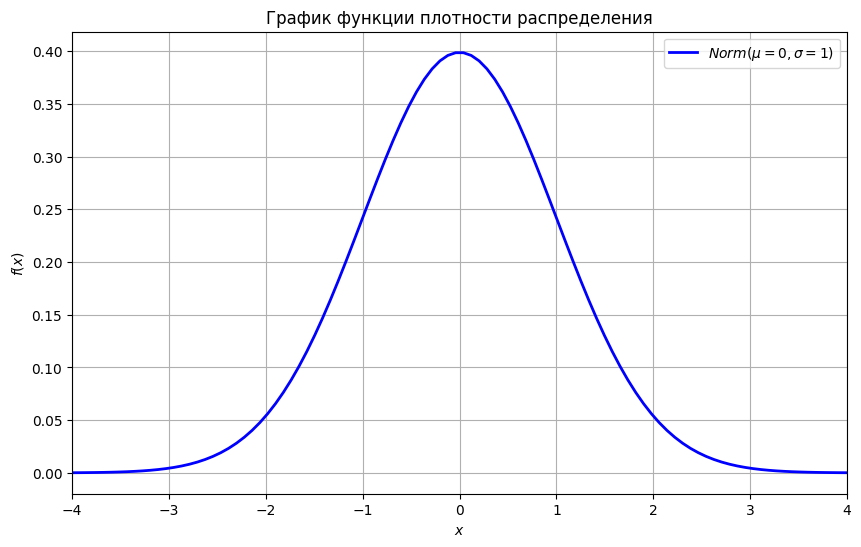

In [3]:
norm_distr_mu = 0  # математическое ожидание
norm_distr_sigma = 1  # среднеквадратичное отклонение

# Демо свойств:
# norm_distr_mu = 2
# norm_distr_sigma = 1

# norm_distr_mu = 0
# norm_distr_sigma = 3

# norm_distr_mu = 0
# norm_distr_sigma = 0.2

# Создание объекта нормального распределения
normal_dist = stats.norm(loc=norm_distr_mu, scale=norm_distr_sigma)

x = np.linspace(-4, 4, 100)
y = normal_dist.pdf(x)

# Построение графика функции плотности распределения
plt.figure(figsize=(10, 6))
plt.plot(
    x, y, "b-", lw=2, label=f"$Norm(\mu={norm_distr_mu}, \sigma={norm_distr_sigma})$"
)

# Добавление дополнительных элементов
plt.title("График функции плотности распределения")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.legend()

# Задание диапазонов для обеих осей
plt.xlim(-4, 4)

plt.show()

**Ключевой момент:**
* вероятность, что непрерывная случайная величина примет значение $x\in\left\lbrack a,b\right\rbrack$ равна
$$ P(x\in[a,b])=\int_a^bf(x)\,\mathrm{d}x $$

Отобразим вероятность $P(x\in[a, b])$ на графике `pdf` имеющегося нормального распределения $Norm(\mu=0, \sigma=1)$.

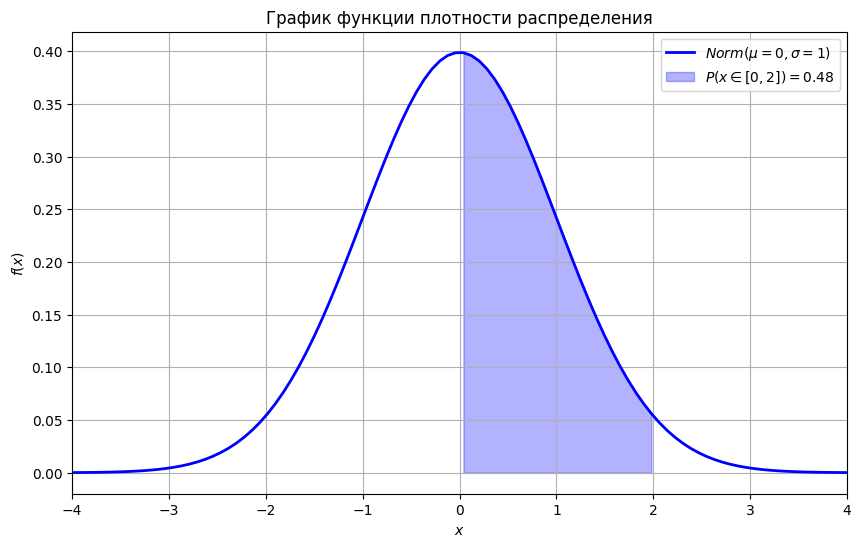

In [4]:
# Построим график нормального распределения
plt.figure(figsize=(10, 6))
plt.plot(
    x, y, "b-", lw=2, label=f"$Norm(\mu={norm_distr_mu}, \sigma={norm_distr_sigma})$"
)

# Определим границы области интегрирования для расчета вероятности
a = 0
b = 2

# Демо свойств:
# a = -1
# b = 1

# a = 1
# b = 1

# a = -4
# b = 4

# Вычисление вероятности попадания в интервал от -1 до 1
probability = normal_dist.cdf(b) - normal_dist.cdf(a)

# Закрашивание области интегрирования соответствующей значению вероятности
plt.fill_between(
    x,
    y,
    where=(x >= a) & (x <= b),
    color="blue",
    alpha=0.3,
    label=f"$P(x\in[{a}, {b}]) = {probability:.2f}$",
)

# Настройка графика
plt.legend()
plt.title("График функции плотности распределения")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)

# Задание диапазонов для обеих осей
plt.xlim(-4, 4)

plt.show()

#### Генерация выборки из распределения

In [5]:
# Генерация 8 случайных чисел с нормальным распределением
normal_numbers = normal_dist.rvs(size=8)

# Вывод результатов
print(normal_numbers)

[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696
  1.57921282  0.76743473]


## Теория вероятности резюме

Все распределения из Теории вероятностей - простейшие модели генераторов чисел с набором параметров $\theta$.

Обозначение $P(\theta \mid x)$ говорит нам:
* Распределение $P$
* с набором параметров $\theta$ каждый из которых равен опр. значению
* для случайной величины, принявшей значение $x$
* отдает нам:

1. значение `функции вероятности (PMF)` для дискретной случ. величины

или

2. значение `функции плотности вероятности (PDF)` для непрерывной случ. величины

Задавая эти параметры, мы получаем точный статистический закон по которому генерируются объекты.

![image](../images/parametric_models.jpg)

В теории вероятностей:

* мы работаем с математическими моделями, которые позволяют моделировать поведение случайных величин.
* мы всегда точно знаем какая модель случайной величины(распределение) генерирует данные и значения параметров $\theta$ этой модели.
* все сгенерированные значения подчиняются этому фундаментальному для них закону.

Теория вероятности дала нам множество моделей с параметрами для генерации объектов.

* Как же создать на их основе генеративную модель?

# Математическая статистика

## Постановка задачи Мат. статистики

Где то мы уже слышали раньше, что то похожее... (см. рисунок ниже).

У нас есть некоторый источник порождающий данные $X^{data}$.

$Х^{data}$ - это случайная величина.

Случайная, т.е. есть Неопределенность. Мы не знаем какое значение будет получено следующим.

Для нас Источник данных это "черная коробочка" или "таинственный сундук".

Как он устроен внутри неизвестно.

Мы наблюдали за Источником, и собрали некоторую выборку $X^{data}$ из экспериментальных данных 

$X^{data}=\left\lbrace X_1^{data}, X_2^{data},X_3^{data}, ...,\right\rbrace$ , размером $n$.

![image](../images/mathematical_statistics.png)

Мы предполагаем, что все объекты выборки:

* `independent` (`независимы`)

Вероятность появления одного объекта выборки не влияет на вероятность появления другого объекта.
См. примеры:
1. Пример зависимых событий (извлечение шаров из урны безвозвратно)
2. Пример независимых событий (извлечение шаров из урны с возвращением)

* `identically distributed` (`одинаково распределены`)

Все объекты выборки имеют одинаковое распределение вероятностей $P_{data}(\theta \mid x)$.

Или по другому, - все объекты выборки были сгенерированы одной моделью $P_{data}(\theta \mid x)$

Это фундаментальное предположение `i.i.d. - Independent and Identically Distributed` (`Независимы и одинаково распределены`) в математической статистике.

Это предположение позволяет нам считать, что все объекты выборки были сгенерированы распределением:

* $P_{data}(\theta=\theta' \mid x)$
* с набором параметров $\theta=\theta'$

Мы не знаем:
* саму модель распределения
* значения ее параметров $\theta'$, с которыми оно генерирует выборку

Специалист по Мат. статистике предполагает опр. модель из Теории вероятностей.

$P_{model}\left(\theta \mid х \right)$

Нужно как то "подобрать" все параметры модели по экспериментальной выборке:

$\left\lbrace X_1^{data}, X_2^{data}, X_3^{data}, ..., X_n^{data} \right\rbrace$

В математической статистике существуют `методы оценки параметров`.

Они позволяют подобрать `оптимальные` значения параметров:

$\theta=\hat{\theta}$

для выбранной модели $P_{model}\left(\theta=\hat{\theta} \mid х \right)$ распределения на экспериментальной выборке $X^{data}$.




Важный момент:

- `Теория вероятностей` предоставляет `модели распределений` для описания случайных величин, а `Математическая статистика` использует эти `модели распределений` для описания экспериментальных данных.

Проводя аналогию с `Машинным обучением`, можно сказать, что `мат. статистка` позволяет "обучать" параметры выбранных моделей из `Теории вероятностей` на экспериментальной выборке.

# Метод максимального правдоподобия (Частотный подход)

Использование данного метода имеет некоторые отличительные особенности при работе
* с непрерывной случайной величиной
* с дискретной случайной величиной

Рассмотрим случай `непрерывной случайно величины`. 

## Непрерывная случайная величина

### Математическая статистика Частотный подход

`Математическая статистика` работает с обратной для `теории вероятностей` ситуацией.

* у нас есть экспериментальная выборка данных $\left\lbrace x_1, x_2, x_3, ..., x_n\right\rbrace$:

```
[-0.26947439, 0.74256004, -0.46341769, -0.56572975, 0.24196227, -1.91328024, -1.52491783, 0.56228753]
```
* мы ничего не знаем о модели статистического распределения, которая генерирует экспериментальную выборку значений случайной величины $x$.
* мы предполагаем что объекты нашей выборки `i.i.d. - Independent and Identically Distributed` (`Независимы и одинаково распределены`)

т.е. что существует некоторая модель статистического распределения

$P_{data}(\theta=\theta' \mid x)=?$

с зафиксированными значениями параметров $\theta=\theta'$ согласно которому сгенерированы наши данные.

* Нужно выбрать модель для статистического распределения.

Которая из соображений `математической статистики`, подходит под наши данные.

* Мы решили выбрать, модель нормального распределения $Norm(\mu, \sigma)$.
* Мы ничего не знаем о его параметрах $\theta=\left\lbrace\mu=?,\sigma=?\right\rbrace$
* Мы можем `подобрать` параметры $\theta=\left\lbrace\mu, \sigma\right\rbrace$, которые лучше всего описывают `имеющиеся на данный момент времени данные`.



### Подбор наиболее правдоподобных параметров для распределения

#### Опытно-экспериментальный подход

**Проблема**:

Два специалиста по мат. статистике предлагают 2 набора параметров для норм. распределения, описывающего наши данные:
1. $\theta_1=\left\lbrace\mu_1=0.5,\sigma_1=1.3\right\rbrace$
2. $\theta_2=\left\lbrace\mu_2=-0.1,\sigma_2=0.8\right\rbrace$

Как узнать какой из наборов описывает процесс генерации наших данные лучше?

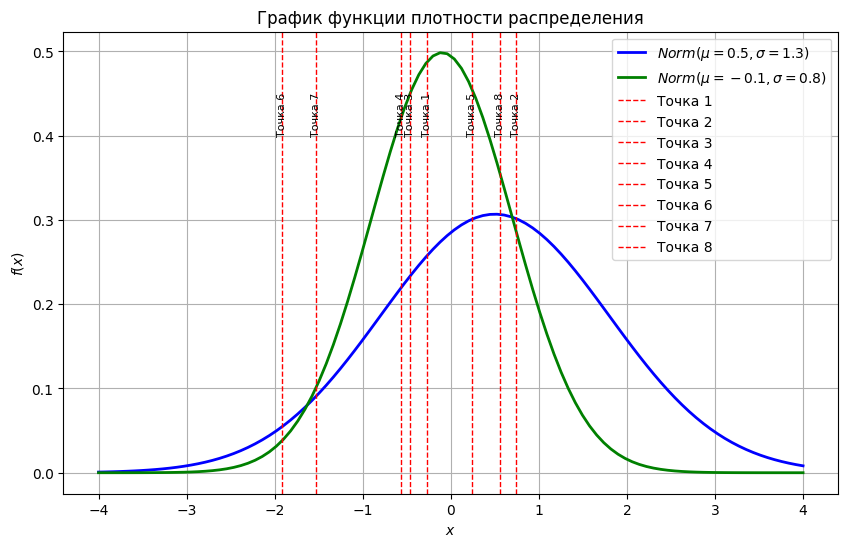

In [6]:
# экспериментальная выборка
x = [
    -0.26947439,
    0.74256004,
    -0.46341769,
    -0.56572975,
    0.24196227,
    -1.91328024,
    -1.52491783,
    0.56228753,
]

# параметры для нормального распределения предложенные
theta_1 = {"mu": 0.5, "sigma": 1.3}  # специалистом 1
theta_2 = {"mu": -0.1, "sigma": 0.8}  # специалистом 2

# создаем нормальные распределения с указанными параметрами
norm_distr_1 = stats.norm(loc=theta_1["mu"], scale=theta_1["sigma"])
norm_distr_2 = stats.norm(loc=theta_2["mu"], scale=theta_2["sigma"])

# Генерация значений для оси X
x_values = np.linspace(-4, 4, 100)
norm_1_y = norm_distr_1.pdf(x_values)
norm_2_y = norm_distr_2.pdf(x_values)

# Построение графика функции плотности распределения
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    x_values,
    norm_1_y,
    "b-",
    lw=2,
    label=f"$Norm(\mu={theta_1['mu']}, \sigma={theta_1['sigma']})$",
)
ax.plot(
    x_values,
    norm_2_y,
    "g-",
    lw=2,
    label=f"$Norm(\mu={theta_2['mu']}, \sigma={theta_2['sigma']})$",
)

# Отмечаем точки экспериментальной выборки на оси X
for i, xi in enumerate(x):
    ax.axvline(xi, color="red", linestyle="--", linewidth=1, label=f"Точка {i+1}")

    # Добавляем текстовую метку
    ax.text(
        xi,
        max(y),
        f"Tочка {i+1}",
        verticalalignment="bottom",
        horizontalalignment="center",
        rotation=90,
        fontsize=8,
    )

# Отображение графика
plt.legend()
plt.title("График функции плотности распределения")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.show()

#### Правдоподобие (Likelihood)

> `Функция правдоподобия (Likelihood function)` это функция для оценки вероятности сгенерировать конкретное значение $x_i$ из нашей выборки выбранным распределением с такими то параметрами $\theta'$.

$L(\theta')=f(\theta' \mid x_i)$

* Ее часто называемая просто `Правдоподобие(Likelihood)`.

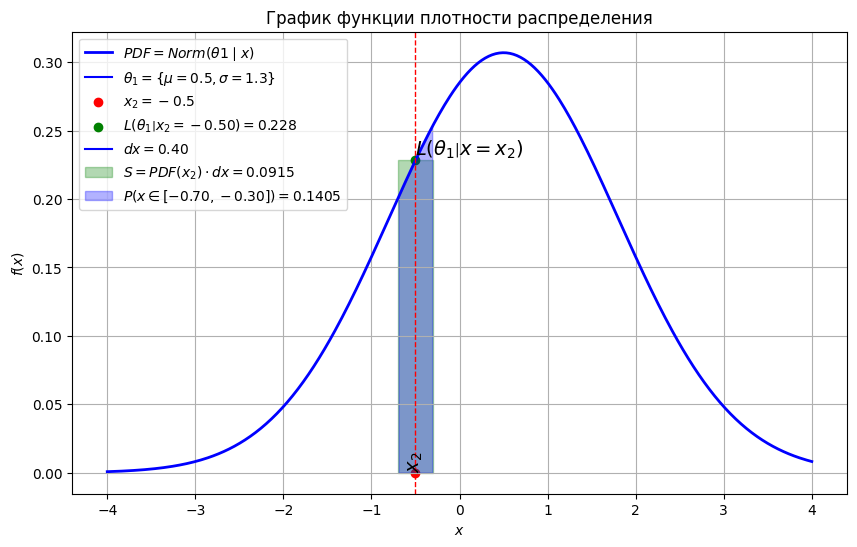

In [16]:
# параметры для нормального распределения предложенные
theta_1 = {"mu": 0.5, "sigma": 1.3}  # специалистом 1

# Визуализируем правдоподобие для точки 2
x2 = -0.5

# Задаем ширину прямоугольника (dx)
dx = (x[1] - x[0]) * 20

# параметры отображения
likelihood_show = True
square_show = True
distr_square_show = True

# создаем нормальное распределение с указанными параметрами
norm_distr_1 = stats.norm(loc=theta_1["mu"], scale=theta_1["sigma"])

# Генерация значений для оси X
x = np.linspace(-4, 4, 400)
y = norm_distr_1.pdf(x)

# Вычисляем Правдоподобие L(x2)
y2 = norm_distr_1.pdf(x2)

# Построение графика функции плотности распределения
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, "b-", lw=2, label=r"$PDF=Norm( \theta1 \mid x)$")

# отображаем параметры распределения на легенде
ax.plot(
    [],
    [],
    "b-",
    label=rf"$\theta_1 = \left\lbrace \mu={theta_1['mu']}, \sigma={theta_1['sigma']} \right\rbrace$",
)

ax.scatter(x2, 0, color="red", label=f"$x_2={x2}$")

# Отмечаем точки экспериментальной выборки на оси X
ax.axvline(x2, color="red", linestyle="--", linewidth=1)
ax.text(
    x2,
    0,
    f"$x_2$",
    verticalalignment="bottom",
    horizontalalignment="center",
    rotation=90,
    fontsize=14,
)

# Добавляем метку Правдоподобия
if likelihood_show:
    ax.scatter(
        x2,
        y2,
        color="green",
        label=rf"$L\left(\theta_1 \left|x_2={x2:.2f}\right.\right)={y2:.3f}$",
    )
    ax.text(
        x2,
        y2,
        r"$L\left(\theta_1 \left| x=x_2 \right.\right)$",
        verticalalignment="bottom",
        horizontalalignment="left",
        fontsize=14,
    )

# Вычисление вероятности попадания в интервал от b до a
if square_show or distr_square_show:
    lower_x, upper_x = x2 - dx / 2, x2 + dx / 2

    # отображаем параметры dx на легенде
    ax.plot([], [], "b-", label=rf"$dx={dx:.2f}$")

# Рисуем прямоугольник площадью y2 * dx
if square_show:
    S = (upper_x - lower_x) * (y2 - 0)
    ax.fill_between(
        [lower_x, upper_x],
        0,
        y2,
        color="green",
        label=f"$S = PDF(x_2) \cdot dx={S:.4f}$",
        alpha=0.3,
    )

# Рисуем истинную площадь распределения
if distr_square_show:
    probability = normal_dist.cdf(upper_x) - normal_dist.cdf(lower_x)
    ax.fill_between(
        x,
        y,
        where=(x >= lower_x) & (x <= upper_x),
        color="blue",
        alpha=0.3,
        label=f"$P(x\in[{lower_x:.2f}, {upper_x:.2f}]) = {probability:.4f}$",
    )

# Отображение графика
plt.legend()
plt.title("График функции плотности распределения")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.show()

Демо:
```
likelihood_show = False
square_show = False
distr_square_show = False
```

* Видим нормальное распределение, с параметрами $Norm(\theta_1 \mid x)$ от специалиста 1.
* Параметры: $\theta_1=\left\lbrace\mu_1=0.5,\sigma_1=1.3\right\rbrace$
* Хотим оценить вероятность появления(генерации) значения $x_2$ в этом распределении.
* Но для непрерывной величины вероятность получить конкретное значение 

$P(\theta_1 \mid x=x_2)= P(\theta_1 \mid x \in [x_2, x_2])=0$

* Как быть?



```
likelihood_show = False
square_show = False
distr_square_show = True
```
* Возьмем некоторую окрестность `dx/2` вокруг нашей точки `x2`
* Можем вычислить вероятность попадания в интервал $P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$

```
likelihood_show = False
square_show = True
distr_square_show = False
```
* Если мы умножим $S = PDF(x_2) \cdot dx$, то получим площадь `S` которая напоминает $P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$

```
likelihood_show = False
square_show = True
distr_square_show = True
```

* Видим, что $S = PDF(x_2) \cdot dx \sim P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$
* При уменьшении $dx \to 0$

$S = PDF(x_2) \cdot dx - P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}]) \to 0$

* Можно сказать, что $PDF(x_2) \cdot dx \sim P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$
* $PDF(x_2) = \frac{1}{dx} \cdot P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$
* $dx=const$ - мы берем его одинаковым для всех точек выборки
* $PDF(x_2) \sim P(\theta_1 \mid x \in [x_2 - \frac{dx}{2}, x_2 + \frac{dx}{2}])$

Для непрерывных случайных величин `Правдоподобие` (`Likelihood`) задается как

$L(\theta)=PDF(\theta \mid x)$

```
likelihood_show = True
square_show = False
distr_square_show = False
```

* Смотрим несколько значений для $L(\theta)=PDF(\theta \mid x)$
* Как вы думаете может ли $L(\theta) > 1$ ?

**Особенность:**

* Значение `Правдоподобия(Likelihood)` меняется с изменением имеющегося набора данных в экспериментальной выборке.

Получили новые данные, можно производить переоценку параметров распределения $\theta$.

#### Вероятность(Probability) Vs Правдоподобие(Likelihood)

Отметим важное отличие между `Вероятностью(Probability)` и `Правдоподобием(Likelihood)` для непрерывной случайной величины.

**Теория вероятности и Вероятность:**
* Известен фундаментальный закон генерации данных (тип распределения и его параметры $\theta$). Все данные подчиняются ему. 
* Все значения генерируемые моделью подчиняется этому фундаментальному закону.
* Вероятность $P(x\in[a, b])$ оценивается для интервала значений $[a, b]$.
* Вероятность получить конкретное значение $x=a$, всегда равна $0$.
* Значение вероятности всегда $P \in [0, 1])$
* Вероятность не зависит от экспериментальных данных, ведь данные всегда удовлетворяют фундаментальному закону.

**Мат. статистика и правдоподобие:**
* Не известен фундаментальный закон генерации данных.
* Мы сами выбираем тип распределения, которым попытаемся описать механизм генерации имеющихся на данный момент времени данных из экспериментальной выборки.
* Мы сами выбираем параметры $\theta$ для  выбранного распределения.
* Правдоподобие оценивает вероятность генерации экспериментального значения согласно выбранному распределению и выбранным для него параметрам: 
  $\mathcal{L}(\theta\mid x=a)=f_{\theta}(x=a)$. При этом значение правдоподобия опр. через значение `функции плотности распределения (PDF)`.
* Правдоподобие определено для конкретного значения $x=a$, не равно $0$ в общем случае.
* Значение `правдоподобия`  $\mathcal{L}(\theta\mid x=a)$ как значение `функции плотности распределения (PDF)` в точке $f_{\theta}(x=a)$ при опр. выборе закона распределения и параметров для него может превышать значение 1-цы:
$$\mathcal{L}(\theta\mid x=a)=f_{\theta}(x=a) > 1$$

* Правдоподобие зависит от экспериментальных данных, и меняется при получении новых.



#### Выбираем лучшие параметры из 2х предложенных наборов $\theta$

Два специалиста по мат. статистике предлагают 2 набора параметров для норм. распределения, описывающего наши данные:
1. $\theta_1=\left\lbrace\mu_1=0.5,\sigma_1=1.3\right\rbrace$
2. $\theta_2=\left\lbrace\mu_2=-0.1,\sigma_2=0.8\right\rbrace$

Как узнать какой из наборов описывает процесс генерации наших данные лучше?

> `Правдоподобие для выборки` оценивает вероятность получить экспериментальные данные $\left\lbrace x_1,x_2,x_3,x_4,...,x_n \right\rbrace$ с помощью выбранного нами типа распределения с фиксированными значениями параметров $\theta$ для этого распределения:

$$\mathcal{L}(\theta\mid x_1,x_2,x_3,x_4,...,x_n)=f_{\theta}(x_1,x_2,x_3,x_4,...,x_n)$$

где для непрерывной случайной величины $f_{\theta}(x)$ это `функция плотности вероятности (PDF)`.

Мы предполагаем, что экспериментальные данные `i.i.d. - Independent and Identically Distributed` (`Независимы и одинаково распределены`).

Учитывая, что каждое значение из наших данных это отдельное наблюдение, которое никак не зависит от предыдущих, можно рассмотреть все как произведение вероятностей независимых событий:

$$\mathcal{L}(\theta\mid x_1,x_2,x_3,x_4,...,x_n) = f_{\theta}(x_1,x_2,x_3,x_4,...,x_n) = f_{\theta}(x_1) \cdot f_{\theta}(x_2) \cdot f_{\theta}(x_1) \cdot ... \cdot f_{\theta}(x_n) = \underset{i=1}{\overset{n}{\prod}}f_{\theta}(x_i) $$

$$\mathcal{L}(\theta\mid x_1,x_2,x_3,x_4,...,x_n) = \underset{i=1}{\overset{n}{\prod}}f_{\theta}(x_i) $$

Чем выше значение `Правдоподобия для выборки` полученное для выбранного типа распределения и набора его параметров $\theta_i$ на наших экспериментальных данных $\left\lbrace x_1,x_2,x_3,x_4,...,x_n \right\rbrace$, тем вероятнее, что данные получены именно такой моделью.

Если 

$$\mathcal{L}(\theta_1\mid x_1,x_2,x_3,x_4,...,x_n) > \mathcal{L}(\theta_2\mid x_1,x_2,x_3,x_4,...,x_n)$$

то говорят, что закон генерации $Norm(\theta_1)$, `более правдоподобен`, чем $Norm(\theta_2)$.

Правдоподобие для выборки, что выборка получена из распределения с параметрами от специалиста 1: 1.83e-06
Правдоподобие для выборки, что выборка получена из распределения с параметрами от специалиста 2: 1.66e-05
L1_for_samples < L2_for_samples ?
True


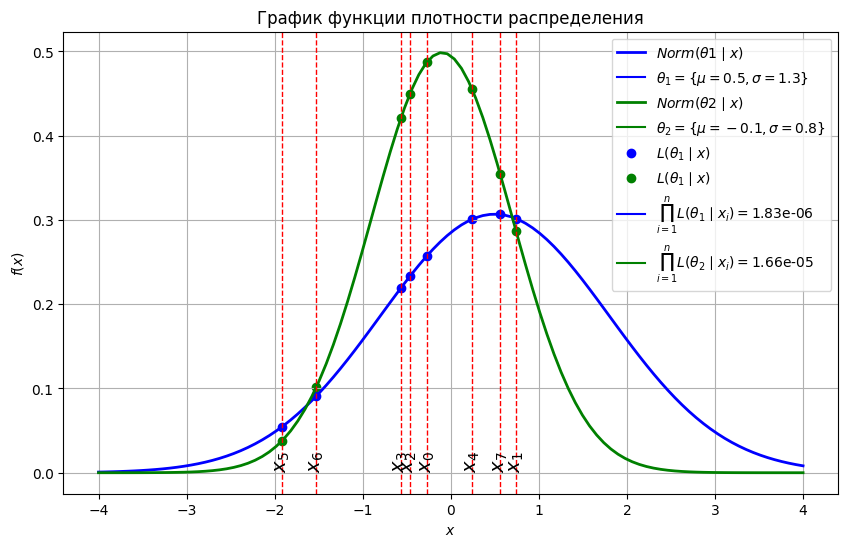

In [11]:
# экспериментальная выборка
x = [
    -0.26947439,
    0.74256004,
    -0.46341769,
    -0.56572975,
    0.24196227,
    -1.91328024,
    -1.52491783,
    0.56228753,
]

# параметры для нормального распределения предложенные
theta_1 = {"mu": 0.5, "sigma": 1.3}  # специалистом 1
theta_2 = {"mu": -0.1, "sigma": 0.8}  # специалистом 2

# создаем нормальные распределения с указанными параметрами
norm_distr_1 = stats.norm(loc=theta_1["mu"], scale=theta_1["sigma"])
norm_distr_2 = stats.norm(loc=theta_2["mu"], scale=theta_2["sigma"])

# Генерация значений для оси X
x_values = np.linspace(-4, 4, 100)
norm_1_y = norm_distr_1.pdf(x_values)
norm_2_y = norm_distr_2.pdf(x_values)

# Построение графика функции плотности распределения
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_values, norm_1_y, "b-", lw=2, label=r"$Norm( \theta1 \mid x)$")
# отображаем параметры распределения на легенде
ax.plot(
    [],
    [],
    "b-",
    label=rf"$\theta_1 = \left\lbrace \mu={theta_1['mu']}, \sigma={theta_1['sigma']} \right\rbrace$",
)
ax.plot(x_values, norm_2_y, "g-", lw=2, label=r"$Norm( \theta2 \mid x)$")
# отображаем параметры распределения на легенде
ax.plot(
    [],
    [],
    "g-",
    label=rf"$\theta_2 = \left\lbrace \mu={theta_2['mu']}, \sigma={theta_2['sigma']} \right\rbrace$",
)

# Отметка точек на оси X
for i, xi in enumerate(x):
    ax.axvline(xi, color="red", linestyle="--", linewidth=1)
    ax.text(
        xi,
        0,
        rf"$x_{i}$",
        verticalalignment="bottom",
        horizontalalignment="center",
        rotation=90,
        fontsize=14,
    )

# Правдоподобия для нормального распределения от специалиста 1
L1 = norm_distr_1.pdf(x)
ax.scatter(x, L1, c="b", label=r"$L(\theta_1 \mid x)$")

# Правдоподобия для нормального распределения от специалиста 2
L2 = norm_distr_2.pdf(x)
ax.scatter(x, L2, c="g", label=r"$L(\theta_1 \mid x)$")

# Считаем Правдоподобия для выборок
L1_for_samples = np.prod(L1)
# отображаем Правдоподобия для выборки на легенде
ax.plot(
    [],
    [],
    "b-",
    label=r"$\underset{i=1}{\overset{n}{\prod}}L(\theta_1 \mid x_i)=$" + f"{L1_for_samples:.2e}",
)
L2_for_samples = np.prod(L2)
# отображаем Правдоподобия для выборки на легенде
ax.plot(
    [],
    [],
    "g-",
    label=r"$\underset{i=1}{\overset{n}{\prod}}L(\theta_2 \mid x_i)=$" + f"{L2_for_samples:.2e}",
)

print(
    f"Правдоподобие для выборки, что выборка получена из распределения с параметрами от специалиста 1: {L1_for_samples:.2e}"
)
print(
    f"Правдоподобие для выборки, что выборка получена из распределения с параметрами от специалиста 2: {L2_for_samples:.2e}"
)
print("L1_for_samples < L2_for_samples ?")
print(L1_for_samples < L2_for_samples)

# Отображение графика
plt.legend()
plt.title("График функции плотности распределения")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.grid(True)
plt.show()

Видим, что $Norm(\theta_2 \mid x)$ от специалиста 2, выглядит `более правдоподобным`, для описания закона по которым генерируются наши экспериментальные данные =)

#### Метод Оценки максимального правдоподобия (Maximum likelihood estimation [сокр. MLE]

**Проблема:**
Поскольку параметры распределения могут принимать бесконечное число различных значений, у нас будет бесконечное множество вариантов различных параметров, и соответствующих им распределений.

`А можно ли сразу найти самые лучшие параметры для выбранного типа распределения, которое лучше всего подойдут в качестве модели-генератора наших данных?`

> `Оценка максимального правдоподобия (Maximum likelihood estimation [MLE])` состоит в подборе такого набора параметров $\widehat{\theta}^{MLE}$ для выбранного распределения при котором `Правдоподобие для выборки` на наших данных достигнет максимума.

$$ {\widehat{\theta}}^{M L E}=\underset{\theta}{\mathrm{argmax}}\,\mathrm{L}(\theta\mid x_{1},\ldots,x_{n})=\underset{\theta}{\mathrm{argmax}}\,\underset{i=1}{\overset{n}{\prod}}f_{\theta}(x_i)$$

Метод `Оценки максимального правдоподобия (MLE)` позволяет работать с различными распределениями как `для непрерывных` так, и `для дискретных` случайных величин.

Нам нужно максимизировать выражение правдоподобия для выборки.

Для этого нам нужно найти его экстремум, доказав, что это максимум.

Полный список шагов:
1. Найти производные функции по всем параметрам модели $\theta$.
2. Приравнять их к нулю и решить уравнения относительно параметров.

Решения этих уравнений ${\widehat{\theta}}^{M L E}$ и будут оптимальными значениями параметров распределения.

Так мы найдем параметры соответствующие особым точкам, но надо бы еще убедится, что это максимум.

3. Берем вторые производные и если они меньше нуля при подстановке наших параметров $\widehat{\theta}^{M L E}$, то мы нашли максимум.

На практике доказывается, что наша функция будет унимодальна - есть только 1 максимум.

И выполняют только шаги 1 и 2.

Попробуем найти производную по всем параметрам модели:

$$ {\widehat{\theta}}^{M L E}=\underset{\theta}{\mathrm{argmax}}\,\mathrm{L}(\theta\mid x_{1},\ldots,x_{n})=\underset{\theta}{\mathrm{argmax}}\,\underset{i=1}{\overset{n}{\prod}}f_{\theta}(x_i)$$

Производная произведения:

* для двух функций: $\left(f g\right)^{\prime}=f^{\prime}g+f g^{\prime}$
* для 3 функций: $(u\cdot v\cdot w)^{\prime}=u^{\prime}\cdot v\cdot w+u\cdot v^{\prime}\cdot w+u\cdot
v\cdot w^{\prime}$

Метод MLE применяется при $n >> d$:
* $d$ - количество параметров которые мы хотим оценить.
* $n$ - размер выборки (датасета)

Для оценки 10 параметров, нужен размер выборки на 1000 объектов минимум.

Произведение 1000 функций, и от этого производную =)

А в датасетах бывает и $10^6$ образцов и как нам считать такие производные?

##### Логарифм правдоподобия и его преимущества

`Логарифм правдоподобия` это $Log(L(\theta) \mid x)$

1. **Инвариантность к монотонным преобразованиям:**

Логарифм — монотонная функция, поэтому максимум логарифма правдоподобия соответствует максимуму самой функции правдоподобия. 

Это означает, что оптимизация логарифма правдоподобия даст те же оценки параметров, что и оптимизация исходной функции правдоподобия.

2. **Логарифм меняет произведение на сумму**

Брать производную от суммы функций гораздо проще, чем от произведения функций:

Производная от суммы функций:

* для 2 функций: $(f+g)^{\prime}=f^{\prime}+g^{\prime}$
* для 3 функций: $(f+g+w)^{\prime}=f^{\prime}+g^{\prime}+w^{\prime}$
* для n функций: $\left({\sum}_{i=1}^nf_i(x)\right)^{\prime}={\sum}_{i=1}^nf_i(x)^{\prime}$


При использовании `логарифма правдоподобия`, выражение задачи для $\widehat{\theta}^{MLE}$ преобразуется в вид:

$$\log L\left(\theta\right)=\log\left(\prod_{i=1}^nf(\theta \mid x_i)\right)=\sum_{i=1}^n\log(f(\theta \mid x_i))$$

Задача оптимизации по максимизации `логарифма правдоподобия` через параметр $\theta$ сведется к поиску экстремума:

$${\frac{\partial log_{}{L}}{\partial\,\theta}}=\sum_{i=1}^n{\frac{\partial log_{}f(x_{i}\mid\theta)}{\partial\,\theta}}=0$$

Решив это уравнение получим оптимальный набор параметров распределения ${\widehat{\theta}}^{MLE}$ для выбранного нами распределения.

Это распределение будет `наиболее правдоподобным` в качестве генератора имеющейся у нас выборки $\left\lbrace x_1,x_2,x_3,x_4,...,x_n \right\rbrace$.

Решение этого уравнения будет различным для различных распределений описывающих нашу случайную величину.

3. Логарифм обеспечивает точность вычислений

Предположим, что нам удается дать ЭВМ задачу на вычисление дифференцирования произведения функций.

Сможем ли мы ее посчитать?

In [124]:
# посмотрим точность для типа float в python
import sys

sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

Наименьшее значение - sys.float_info.min (2.2250788585072014e-308)

Наибольшее значение - sys.float_info.max (1.7976931348623157e+308)

Подробности в документации [ссылка](https://translated.turbopages.org/proxy_u/en-ru.ru.0aad166c-66e14549-6e642a45-74722d776562/docs.python.org/library/sys.html#sys.float_info).

При достаточно большом количестве перемножений плотностей вероятности мы можем выйти за данный предел точности.

Предположительно это может случится при расчете вероятности появления картинки персонажа с опр. стилем. Там около 500 пикселей, на каждый из RGB-каналов изображения, итого 1500.

In [13]:
print(10**(-308)) # все еще маленькое значение
print(10**(-350)) # наше маленькое значение превратилось в 0

# ситуация, которой мы опасаемся перемножение большого числа маленьких
# плотностей вероятностей превращается в ноль из за ограничений точности
p = 10**(-308)
print(p * p * p) 

1e-308
0.0
0.0


Использование логарифмов существенно повышает точность вычислений:

In [14]:
# маленькая вероятность превратилась в небольшое число
print(np.log10(p))

# использование логарифма
p = np.log10(p)
print(p * p * p) 

-308.0
-29218112.0


Точность вычислений повысилась до $10^{-29218112}$ при ограничении на $10^{-308}$ для float в Python.

Можно использовать логарифм любого основания, при этом $log_{10}$ интуитивно позволяет сразу представить себе порядок величины.

$$log_{10}(x)=2, x=100$$
$$log_{10}(x)=3, x=1000$$
$$log_{10}(x)=2.5, x \in [100,1000]$$

основание 10 удобно =)

#### MLE для нормального распределения

Применяем метод `MLE` к нормальному распределению.

1. Берем формулу `функции плотности вероятностей (PDF)` для нормального распределения:
$$f(\mu, \sigma^2 \mid x)={\frac{1}{\sqrt{2\pi\sigma^{2}}}}\exp\left(-{\frac{(x-\mu)^{2}}{2\sigma^{2}}}\right)$$

2. `Правдоподобие для выборки`:

Для нашей выборки $X=\{x_{1},x_{2},\ldots,x_{n}\}$ `правдоподобие для выборки` $L(\mu,\sigma^{2} \mid X)$ запишется как 
$$L(\mu,\sigma^{2} \mid X)=\prod_{i=1}^{n}f(\mu,\sigma^{2} \mid x_{i})$$

Подставляя формулу для `функции плотности вероятностей (PDF)`, получаем:

$$L(\mu,\sigma^{2} \mid X)=\prod_{i=1}^{n}{\frac{1}{\sqrt{2\pi\sigma^{2}}}}\exp\left(-{\frac{(x_{i}-\mu)^{2}}{2\sigma^{2}}}\right)$$

3. `Логарифм правдоподобия для выборки`:

Чтобы иметь возможность это посчитать используем `Логарифм правдоподобия для выборки`:

* чтобы избавится от экспоненты, удобно взять `натуральный логарифм` $ln()$.

$$\ln L(\mu,\sigma^2\mid X)={\textstyle \sum_{i=1}^n\ln f(\mu,\sigma^2\mid x_i)}$$

Подставляя формулу `функции плотности вероятностей (PDF)`, получаем:

$$\ln L(\mu,\sigma^{2} \mid X)=-\frac{n}{2}\ln(2\pi\sigma^{2})-\sum_{i=1}^{n}\frac{(x_{i}-\mu)^{2}}{2\sigma^{2}}$$

4. Максимизация логарифма правдоподобия:

Чтобы найти оценки $\hat{\mu}$ и $\hat{\sigma}^2$, которые максимизируют `логарифм правдоподобия`, нужно взять частные производные по $\mu$ и $\sigma^2$ и приравнять их к нулю.

- Берем производную по $\mu$ и приравниваем ее к 0:

Исходное выражение:

$$\ln L(\mu,\sigma^{2} \mid X)=-\frac{n}{2}\ln(2\pi\sigma^{2})-\sum_{i=1}^{n}\frac{(x_{i}-\mu)^{2}}{2\sigma^{2}}$$

Взяли производную и приравняли ее к нулю:

$$\frac{\partial \ln L}{\partial \mu} = \sum_{i=1}^{n} \frac{(x_i - \mu)}{\sigma^2} = 0$$

* Решением этого уравнения будет уже оптимальное значение для параметра $\mu$ полученное методом `MLE`.
* Обозначим это значение как $\hat\mu^{MLE}$

Запишем без лишнего:

$$\sum_{i=1}^{n} \frac{(x_i - \hat\mu^{MLE})}{\sigma^2} = 0$$

Умножим на обе части уравнения на $\sigma^2$:

$$\sum_{i=1}^n(x_i-\hat\mu^{MLE})=0$$

$\hat\mu^{MLE}=const$ можно вынести за знак суммы умножив на $n$: 

$$\sum_{i=1}^{n} x_i - n\hat\mu^{MLE} = 0$$

Перенесли $n\hat\mu^{MLE}$ в право, и поделили на $n$:

$$\hat{\mu}^{MLE} = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{x}$$

Таким образом, оценка $\hat{\mu}^{MLE}$ — это выборочное среднее $\bar{x}$.

- Берем производную по $\sigma^2$ как по переменной и приравниваем ее к 0:

Исходное выражение:

$$\ln L(\mu,\sigma^{2} \mid X)=-\frac{n}{2}\ln(2\pi\sigma^{2})-\sum_{i=1}^{n}\frac{(x_{i}-\mu)^{2}}{2\sigma^{2}}$$

Взяли производную:

$$\frac{\partial\ln L}{\partial\sigma^{2}}=-\frac{n}{2\sigma^{2}}+\sum_{i=1}^{n}\frac{(x_{i}-\mu)^{i}}{2(\sigma^{2})^{2}}=0$$

* Решением этого уравнения будет уже оптимальное значение для параметра $\sigma^2$ полученное методом `MLE`.
* Обозначим это значение как $\hat\sigma^2$

Запишем без лишнего:

$$-\frac{n}{2\hat\sigma^2} + \frac{1}{2(\hat\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

Умножим обе части уравнения на $2(\hat\sigma^2)^2$, чтобы избавиться от дробей:

$$-\frac{n}{2\hat\sigma^2} \cdot {2(\hat\sigma^2)^{2}} + \frac{1}{\cancel{2(\hat\sigma^2)^2}} \cdot {\cancel{2(\hat\sigma^2)^2}} \sum_{i=1}^{n} (x_i - \mu)^2 = 0 \cdot 2(\hat\sigma^2)^2$$

Упрощаем:
$$-\frac{n(\hat\sigma^2)^2}{\hat\sigma^2} + \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

Сократим $\hat\sigma^2$ в первом члене:
$$-n\hat\sigma^2 + \sum_{i=1}^{n} (x_i - \mu)^2 = 0$$

Перенесем $-n\hat\sigma^2$ в правую часть уравнения:
$$\sum_{i=1}^{n} (x_i - \mu)^2 = n\hat\sigma^2$$

Разделим обе части уравнения на $n$:
$$\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2 = \hat\sigma^2$$

$$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

Извлекаем корень:

$$\hat\sigma^{MLE}=\sqrt{\frac{1}{n}\underset{i=1}{\overset{n}{\sum}}\left(x_i-\overline{x}\right)^2}$$

Корень из выборочной дисперсии называется выборочным стандартным отклонением (sample standard deviation). 

P.S. Подробный вывод показан в видео([ссылка](https://youtu.be/mH8022OsfuI?si=0nRaiaLBtK2FTshu)) у Филлипа Ульянкина.

Итоговые оптимальные параметры по методу MLE для нормального распределения:

* оптимальный $\mu$ это выборочное среднее:

$$\hat\mu^{MLE}=\overline{x}={\frac{1}{n}} \underset{i=1}{\overset{n}{\sum}}x_{i}$$

* оптимальный $\sigma$ это выборочное стандартное отклонение:

$$\hat\sigma^{MLE}=\sqrt{\frac{1}{n}\underset{i=1}{\overset{n}{\sum}}\left(x_i-\overline{x}\right)^2}$$

# Дополнительные материалы

1. MLE для нормального распределения

P.S. Подробный вывод показан в видео([ссылка](https://youtu.be/mH8022OsfuI?si=0nRaiaLBtK2FTshu)) у Филлипа Ульянкина.